# 02 — Graph Construction & Spatial Analysis
Build the road network graph from sensor correlations and analyze its properties.

**Key outputs:** Adjacency matrix, Chebyshev polynomials (STGCN), Diffusion matrices (DCRNN)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import config
from src.config import set_seed
from src.data_loader import load_csv, handle_missing_values

set_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Training Data
Graph is constructed using **training data only** to prevent data leakage.

In [2]:
raw_data, sensor_ids, timestamps = load_csv(config.METR_LA_PATH)
cleaned = handle_missing_values(raw_data)

train_end = int(len(cleaned) * config.TRAIN_RATIO)
train_data = cleaned[:train_end]
print(f"Training data shape: {train_data.shape}")
print(f"Number of sensors (nodes): {train_data.shape[1]}")
print(f"Training timesteps: {train_data.shape[0]}")

Loading /home/anonymous/GraphNN/dataset/METR-LA.csv...
  Shape: (34272, 207) (timesteps × sensors)
  Time range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
  Missing values: 0 (0.00%)
  Zero values: 575302 (8.11%)
  After cleaning — NaN: 0, Zeros: 0
Training data shape: (23990, 207)
Number of sensors (nodes): 207
Training timesteps: 23990


## 2. Pairwise Correlation Matrix
Pearson correlation between all sensor pairs — this is the basis for our graph.

Correlation matrix shape: (207, 207)
Mean correlation: 0.2002
Min correlation:  -0.4959
Max correlation:  0.9788


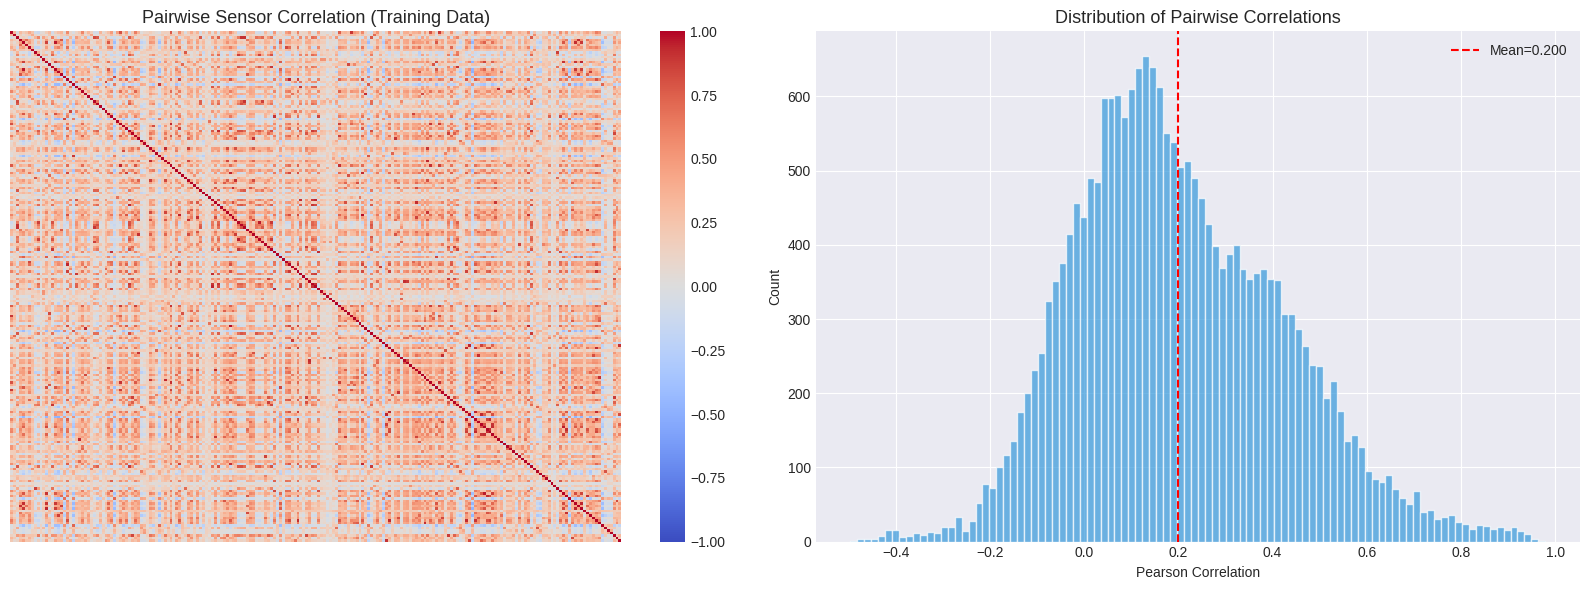

In [3]:
corr_matrix = np.corrcoef(train_data.T)
corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Mean correlation: {corr_matrix[np.triu_indices_from(corr_matrix, k=1)].mean():.4f}")
print(f"Min correlation:  {corr_matrix[np.triu_indices_from(corr_matrix, k=1)].min():.4f}")
print(f"Max correlation:  {corr_matrix[np.triu_indices_from(corr_matrix, k=1)].max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=axes[0],
            xticklabels=False, yticklabels=False, vmin=-1, vmax=1)
axes[0].set_title('Pairwise Sensor Correlation (Training Data)', fontsize=13)

# Histogram of correlations
upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
axes[1].hist(upper_tri, bins=100, color='#3498db', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribution of Pairwise Correlations', fontsize=13)
axes[1].set_xlabel('Pearson Correlation')
axes[1].set_ylabel('Count')
axes[1].axvline(upper_tri.mean(), color='red', linestyle='--', label=f'Mean={upper_tri.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Gaussian Kernel — Build Adjacency Matrix
Formula: `A[i,j] = exp(-((1 - corr[i,j])^2) / (2 * σ²))`
Then apply sparsity threshold ε.

In [4]:
from src.graph_builder import compute_correlation_adj

# Test different sigma and epsilon values
sigmas = [0.05, 0.1, 0.2, 0.5]
epsilons = [0.1, 0.3, 0.5, 0.7]

print(f"{'Sigma':>8} {'Epsilon':>8} {'Edges':>8} {'Sparsity':>10} {'Avg Degree':>10}")
print("-" * 50)
for s in sigmas:
    for e in [0.3]:
        adj = compute_correlation_adj(train_data, sigma=s, epsilon=e)
        edges = np.count_nonzero(adj) - len(adj)  # exclude self-loops
        sparsity = 1 - np.count_nonzero(adj) / (len(adj) ** 2)
        avg_deg = edges / len(adj)
        print(f"{s:>8.2f} {e:>8.2f} {edges:>8d} {sparsity:>10.2%} {avg_deg:>10.1f}")

print()
for e in epsilons:
    adj = compute_correlation_adj(train_data, sigma=0.1, epsilon=e)
    edges = np.count_nonzero(adj) - len(adj)
    sparsity = 1 - np.count_nonzero(adj) / (len(adj) ** 2)
    avg_deg = edges / len(adj)
    print(f"{0.1:>8.2f} {e:>8.2f} {edges:>8d} {sparsity:>10.2%} {avg_deg:>10.1f}")

   Sigma  Epsilon    Edges   Sparsity Avg Degree
--------------------------------------------------
  Adjacency matrix: 207x207
  Non-zero entries: 255 / 42849
  Sparsity: 99.40%
  Avg connections per node: 1.2
    0.05     0.30       48     99.40%        0.2
  Adjacency matrix: 207x207
  Non-zero entries: 447 / 42849
  Sparsity: 98.96%
  Avg connections per node: 2.2
    0.10     0.30      240     98.96%        1.2
  Adjacency matrix: 207x207
  Non-zero entries: 1187 / 42849
  Sparsity: 97.23%
  Avg connections per node: 5.7
    0.20     0.30      980     97.23%        4.7
  Adjacency matrix: 207x207
  Non-zero entries: 17821 / 42849
  Sparsity: 58.41%
  Avg connections per node: 86.1
    0.50     0.30    17614     58.41%       85.1

  Adjacency matrix: 207x207
  Non-zero entries: 631 / 42849
  Sparsity: 98.53%
  Avg connections per node: 3.0
    0.10     0.10      424     98.53%        2.0
  Adjacency matrix: 207x207
  Non-zero entries: 447 / 42849
  Sparsity: 98.96%
  Avg connection

  Adjacency matrix: 207x207
  Non-zero entries: 447 / 42849
  Sparsity: 98.96%
  Avg connections per node: 2.2

Final adjacency: σ=0.1, ε=0.3
Shape: (207, 207)


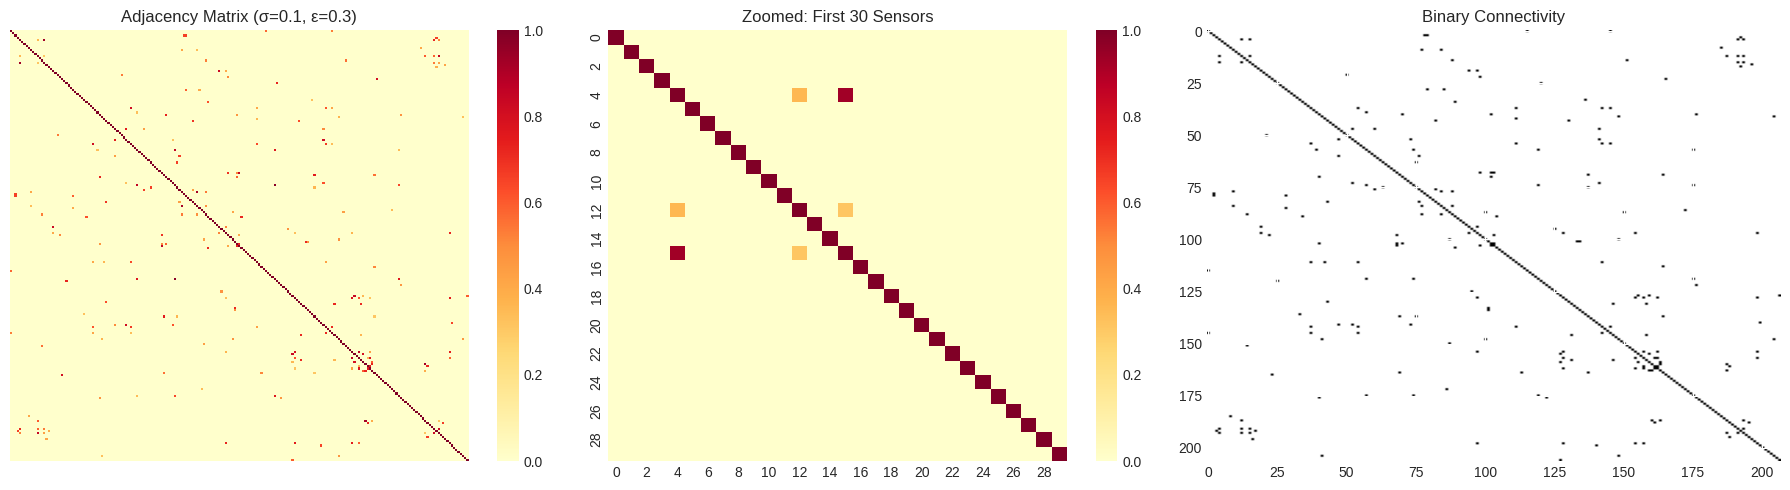

In [5]:
# Build final adjacency with chosen parameters
adj = compute_correlation_adj(train_data, sigma=config.GRAPH_SIGMA, epsilon=config.GRAPH_EPSILON)
print(f"\nFinal adjacency: σ={config.GRAPH_SIGMA}, ε={config.GRAPH_EPSILON}")
print(f"Shape: {adj.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full adjacency
sns.heatmap(adj, cmap='YlOrRd', ax=axes[0], xticklabels=False, yticklabels=False)
axes[0].set_title(f'Adjacency Matrix (σ={config.GRAPH_SIGMA}, ε={config.GRAPH_EPSILON})', fontsize=12)

# Zoomed 30x30
sns.heatmap(adj[:30, :30], cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Zoomed: First 30 Sensors', fontsize=12)

# Binary version
axes[2].imshow(adj > 0, cmap='binary', aspect='auto')
axes[2].set_title('Binary Connectivity', fontsize=12)

plt.tight_layout()
plt.savefig('../results/plots/adjacency_construction.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Graph Properties Analysis

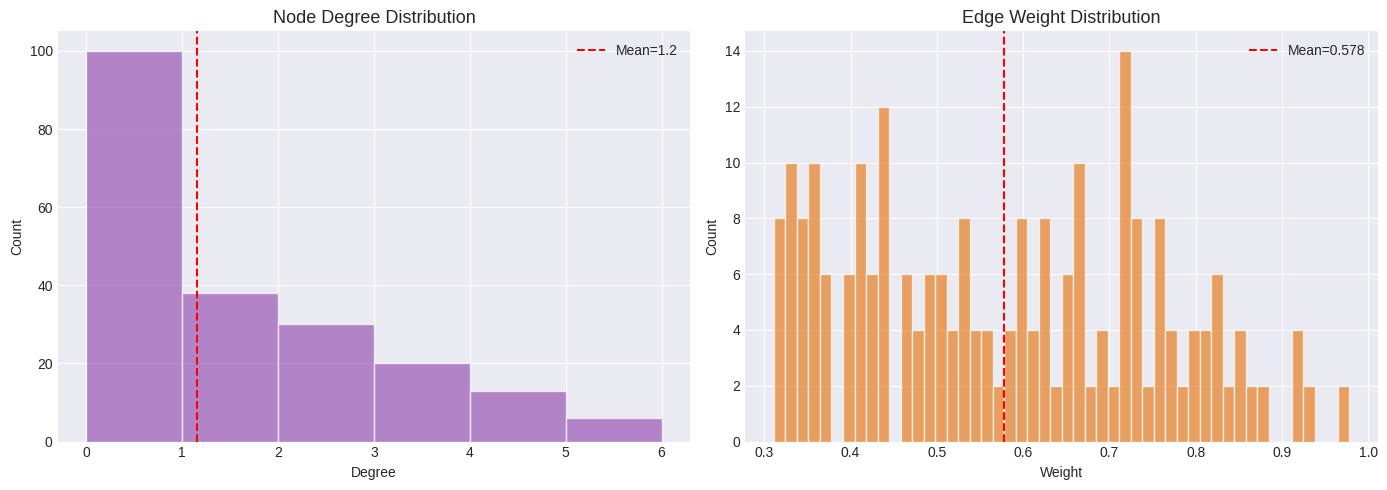

Graph Statistics:
  Nodes: 207
  Edges: 240
  Avg degree: 1.2
  Max degree: 5
  Min degree: 0
  Isolated nodes (degree 0): 100
  Avg edge weight: 0.5779
  Symmetric: True


In [6]:
# Degree distribution
degrees = (adj > 0).sum(axis=1) - 1  # exclude self-loops

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degrees, bins=range(0, int(degrees.max()) + 2), color='#9b59b6',
             alpha=0.7, edgecolor='white')
axes[0].set_title('Node Degree Distribution', fontsize=13)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].axvline(degrees.mean(), color='red', linestyle='--', label=f'Mean={degrees.mean():.1f}')
axes[0].legend()

# Edge weight distribution
edge_weights = adj[adj > 0]
edge_weights = edge_weights[edge_weights < 1.0]  # exclude self-loops
axes[1].hist(edge_weights, bins=50, color='#e67e22', alpha=0.7, edgecolor='white')
axes[1].set_title('Edge Weight Distribution', fontsize=13)
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Count')
axes[1].axvline(edge_weights.mean(), color='red', linestyle='--', label=f'Mean={edge_weights.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/graph_properties.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Graph Statistics:")
print(f"  Nodes: {len(adj)}")
print(f"  Edges: {int(degrees.sum())}")
print(f"  Avg degree: {degrees.mean():.1f}")
print(f"  Max degree: {int(degrees.max())}")
print(f"  Min degree: {int(degrees.min())}")
print(f"  Isolated nodes (degree 0): {(degrees == 0).sum()}")
print(f"  Avg edge weight: {edge_weights.mean():.4f}")
print(f"  Symmetric: {np.allclose(adj, adj.T)}")

## 5. Symmetric Normalization (for STGCN)
`D^(-1/2) A D^(-1/2)` — used for spectral graph convolution

Normalized adjacency range: [0.0000, 1.0000]
Row sums (should be ≤ 1): mean=0.9982

Chebyshev polynomials computed: K=3
  T_0: shape=(207, 207), range=[0.0000, 1.0000]
  T_1: shape=(207, 207), range=[-1.0000, 0.4159]
  T_2: shape=(207, 207), range=[-0.5200, 1.0000]
  T_3: shape=(207, 207), range=[-1.0000, 0.7223]


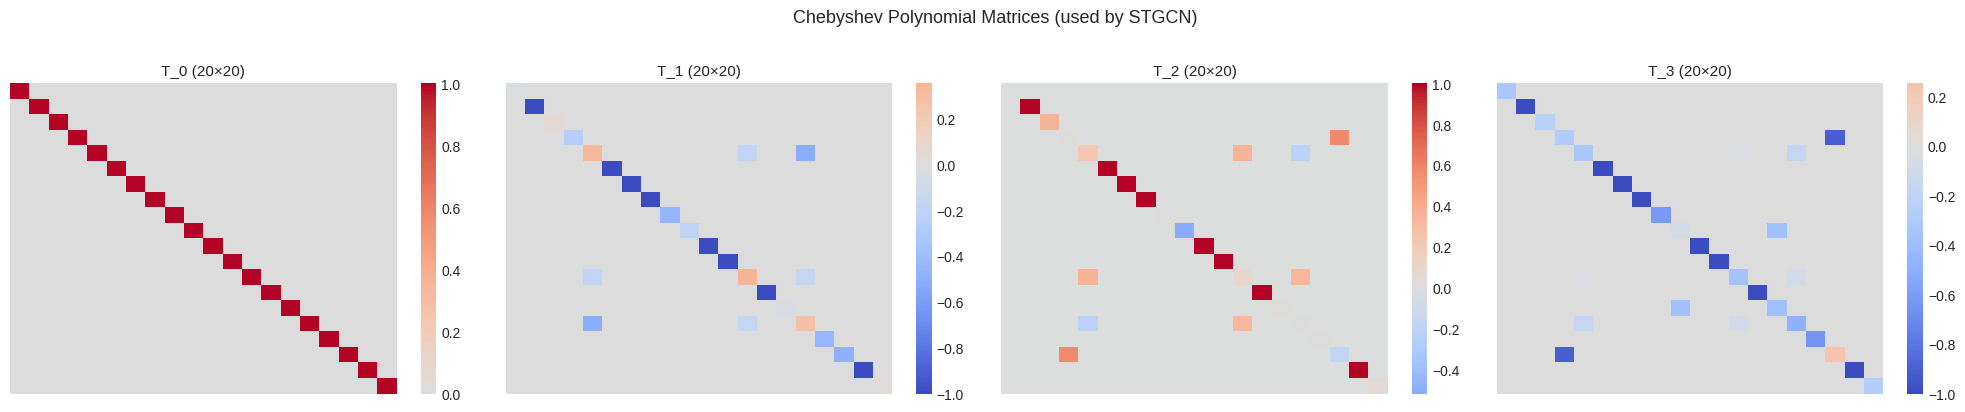

In [7]:
from src.graph_builder import symmetric_normalize, compute_chebyshev_polynomials

adj_sym = symmetric_normalize(adj)
print(f"Normalized adjacency range: [{adj_sym.min():.4f}, {adj_sym.max():.4f}]")
print(f"Row sums (should be ≤ 1): mean={adj_sym.sum(axis=1).mean():.4f}")

# Chebyshev polynomials
cheb_polys = compute_chebyshev_polynomials(adj_sym, K=config.STGCN_K)
print(f"\nChebyshev polynomials computed: K={config.STGCN_K}")
for i, p in enumerate(cheb_polys):
    print(f"  T_{i}: shape={p.shape}, range=[{p.min():.4f}, {p.max():.4f}]")

fig, axes = plt.subplots(1, len(cheb_polys), figsize=(5 * len(cheb_polys), 4))
for i, p in enumerate(cheb_polys):
    sns.heatmap(p[:20, :20], cmap='coolwarm', center=0, ax=axes[i],
                xticklabels=False, yticklabels=False)
    axes[i].set_title(f'T_{i} (20×20)', fontsize=11)
plt.suptitle('Chebyshev Polynomial Matrices (used by STGCN)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/plots/chebyshev_polynomials.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Diffusion Matrices (for DCRNN)
Bidirectional random walk: forward `D_O^(-1)W` and backward `D_I^(-1)W^T`

Diffusion supports: 4 matrices
  Forward step 1: range=[0.0000, 1.0000], row sum mean=1.0000
  Backward step 1: range=[0.0000, 1.0000], row sum mean=1.0000
  Forward step 2: range=[0.0000, 1.0000], row sum mean=1.0000
  Backward step 2: range=[0.0000, 1.0000], row sum mean=1.0000


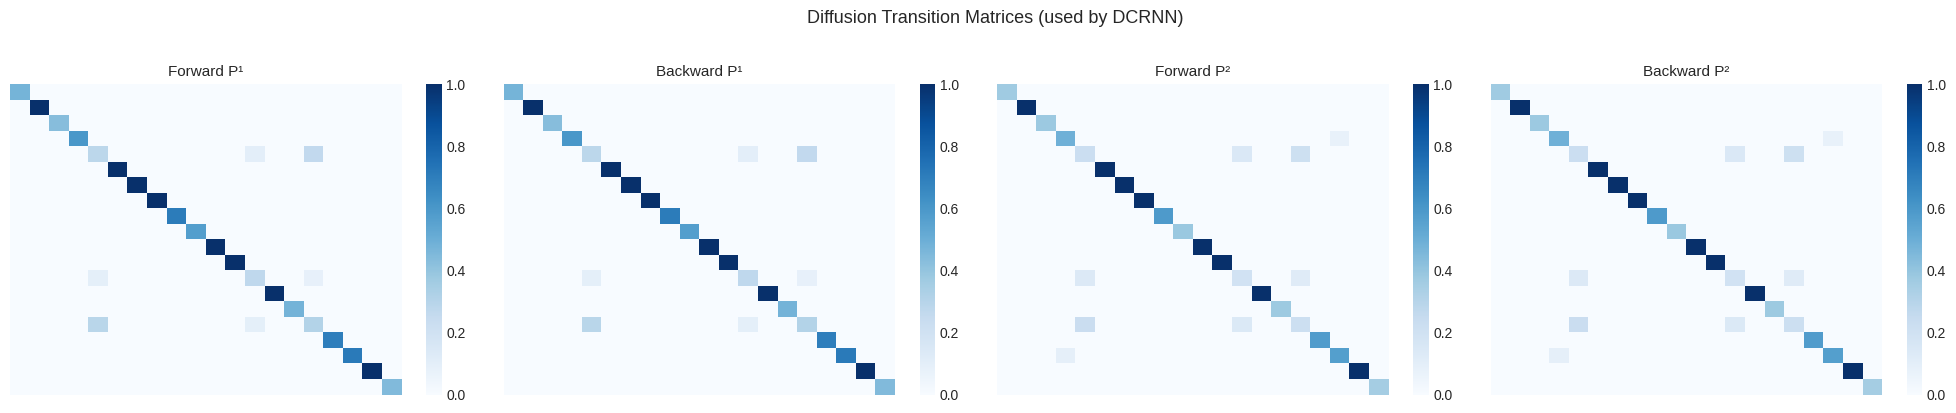

In [8]:
from src.graph_builder import compute_diffusion_matrices

supports = compute_diffusion_matrices(adj, K=config.DIFFUSION_STEPS)
print(f"Diffusion supports: {len(supports)} matrices")
for i, s in enumerate(supports):
    direction = "Forward" if i % 2 == 0 else "Backward"
    step = i // 2 + 1
    print(f"  {direction} step {step}: range=[{s.min():.4f}, {s.max():.4f}], "
          f"row sum mean={s.sum(axis=1).mean():.4f}")

fig, axes = plt.subplots(1, len(supports), figsize=(5 * len(supports), 4))
labels = ['Forward P¹', 'Backward P¹', 'Forward P²', 'Backward P²']
for i, s in enumerate(supports):
    sns.heatmap(s[:20, :20], cmap='Blues', ax=axes[i], xticklabels=False, yticklabels=False)
    axes[i].set_title(labels[i] if i < len(labels) else f'Support {i}', fontsize=11)
plt.suptitle('Diffusion Transition Matrices (used by DCRNN)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/plots/diffusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Graph for Later Use

In [9]:
from src.graph_builder import save_graph, build_graph

graph_data = build_graph(train_data, sigma=config.GRAPH_SIGMA,
                         epsilon=config.GRAPH_EPSILON,
                         K_cheb=config.STGCN_K, K_diff=config.DIFFUSION_STEPS)

save_graph(graph_data, '../results', 'METR-LA')
print("\nGraph saved! Can be loaded with load_graph() later.")
print(f"\nGraph data keys: {list(graph_data.keys())}")

Building graph from sensor correlations...
  Adjacency matrix: 207x207
  Non-zero entries: 447 / 42849
  Sparsity: 98.96%
  Avg connections per node: 2.2
  Computing Chebyshev polynomials...
  Computing diffusion matrices...
Graph construction complete.

Graph saved to ../results/METR-LA_graph.npz

Graph saved! Can be loaded with load_graph() later.

Graph data keys: ['adj', 'adj_sym', 'cheb_polys', 'diffusion_supports']
